<a href="https://colab.research.google.com/github/lethienan7407-gif/BTVN-W1/blob/main/BTVN-W2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikit-fuzzy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 3.9 MB/s eta 0:00:00


Mời khách hàng nhập đánh giá (Rating từ 1 đến 5 sao): 4.5
------------------------------
KẾT QUẢ TÍNH TOÁN:
Giá cước cuối cùng: 93.51
Điểm thưởng tài xế: 92.78
------------------------------


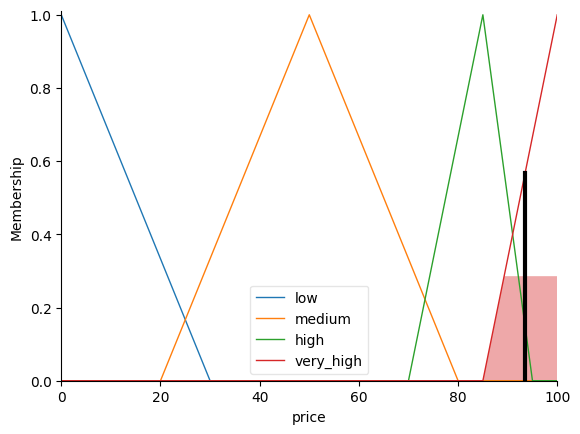

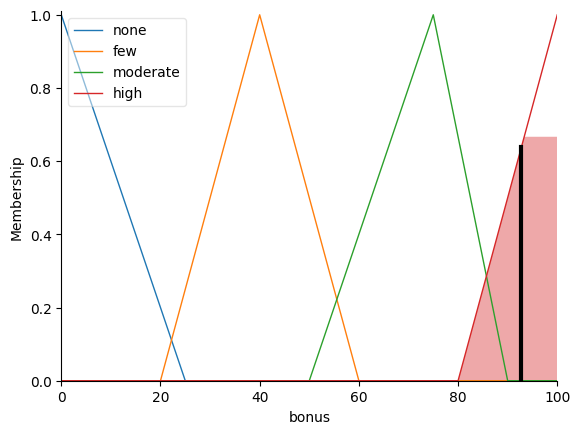

In [ ]:
import numpy as np
import skfuzzy as fuzzy
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt


distance = ctrl.Antecedent(np.arange(0, 51, 1), 'distance')
traffic = ctrl.Antecedent(np.arange(0, 101, 1), 'traffic')
demand = ctrl.Antecedent(np.arange(0, 101, 1), 'demand')
weather = ctrl.Antecedent(np.arange(0, 11, 1), 'weather')
rating = ctrl.Antecedent(np.arange(1, 6, 1), 'rating')
punctuality = ctrl.Antecedent(np.arange(0, 101, 1), 'punctuality')

price = ctrl.Consequent(np.arange(0, 101, 1), 'price')
bonus = ctrl.Consequent(np.arange(0, 101, 1), 'bonus')


distance['short'] = fuzzy.trimf(distance.universe, [0, 0, 3])
distance['medium'] = fuzzy.trimf(distance.universe, [2, 5, 8])
distance['long'] = fuzzy.trimf(distance.universe, [6, 13, 20])
distance['very_long'] = fuzzy.trimf(distance.universe, [15, 50, 50])

traffic['low'] = fuzzy.trimf(traffic.universe, [0, 0, 30])
traffic['medium'] = fuzzy.trimf(traffic.universe, [20, 45, 70])
traffic['high'] = fuzzy.trimf(traffic.universe, [60, 100, 100])

demand['low'] = fuzzy.trimf(demand.universe, [0, 0, 30])
demand['medium'] = fuzzy.trimf(demand.universe, [20, 45, 70])
demand['high'] = fuzzy.trimf(demand.universe, [60, 100, 100])

weather['good'] = fuzzy.trimf(weather.universe, [0, 0, 5])
weather['moderate'] = fuzzy.trimf(weather.universe, [3, 5, 7])
weather['bad'] = fuzzy.trimf(weather.universe, [5, 10, 10])

rating['poor'] = fuzzy.trimf(rating.universe, [1, 1, 2.5])
rating['average'] = fuzzy.trimf(rating.universe, [2, 3, 4])
rating['good'] = fuzzy.trimf(rating.universe, [3.5, 5, 5])

punctuality['late'] = fuzzy.trimf(punctuality.universe, [0, 0, 50])
punctuality['on_time'] = fuzzy.trimf(punctuality.universe, [40, 60, 80])
punctuality['early'] = fuzzy.trimf(punctuality.universe, [70, 100, 100])

price['low'] = fuzzy.trimf(price.universe, [0, 0, 30])
price['medium'] = fuzzy.trimf(price.universe, [20, 50, 80])
price['high'] = fuzzy.trimf(price.universe, [70, 85, 95])
price['very_high'] = fuzzy.trimf(price.universe, [85, 100, 100])

bonus['none'] = fuzzy.trimf(bonus.universe, [0, 0, 25])
bonus['few'] = fuzzy.trimf(bonus.universe, [20, 40, 60])
bonus['moderate'] = fuzzy.trimf(bonus.universe, [50, 75, 90])
bonus['high'] = fuzzy.trimf(bonus.universe, [80, 100, 100])


rules = [
    ctrl.Rule(distance['short'] & traffic['low'] & demand['low'], price['low']),
    ctrl.Rule(distance['short'] & traffic['medium'] & demand['high'], price['medium']),
    ctrl.Rule(distance['medium'] & traffic['high'] & demand['high'], price['high']),
    ctrl.Rule(distance['long'] & traffic['medium'] & weather['good'], price['medium']),
    ctrl.Rule(distance['long'] & traffic['high'] & weather['bad'], price['very_high']),
    ctrl.Rule(distance['very_long'] & traffic['high'] & demand['high'], price['very_high']),
    ctrl.Rule(distance['medium'] & traffic['low'] & demand['low'], price['medium']),
    ctrl.Rule(distance['short'] & traffic['high'] & weather['bad'], price['high']),
    ctrl.Rule(distance['very_long'] & weather['bad'], price['very_high']),
    ctrl.Rule(distance['medium'] & traffic['medium'] & weather['moderate'], price['medium']),

    ctrl.Rule(rating['good'] & punctuality['early'], bonus['high']),
    ctrl.Rule(rating['average'] & punctuality['on_time'], bonus['moderate']),
    ctrl.Rule(rating['poor'] & punctuality['late'], bonus['none']),
    ctrl.Rule(distance['long'] & traffic['high'] & punctuality['on_time'], bonus['high']),
    ctrl.Rule(distance['medium'] & traffic['medium'] & rating['good'], bonus['moderate']),
    ctrl.Rule(distance['very_long'] & weather['bad'] & rating['good'], bonus['high']),
    ctrl.Rule(distance['short'] & rating['average'] & punctuality['on_time'], bonus['few']),
    ctrl.Rule(distance['long'] & traffic['high'] & punctuality['late'], bonus['few']),
    ctrl.Rule(distance['medium'] & weather['moderate'] & rating['good'], bonus['moderate'])
]


grab_ctrl = ctrl.ControlSystem(rules)
grab_sim = ctrl.ControlSystemSimulation(grab_ctrl)


grab_sim.input['distance'] = 18
grab_sim.input['traffic'] = 75
grab_sim.input['demand'] = 80
grab_sim.input['weather'] = 8
grab_sim.input['punctuality'] = 90


while True:
    try:
        val = float(input("Mời khách hàng nhập đánh giá (Rating từ 1 đến 5 sao): "))
        if 1 <= val <= 5:
            grab_sim.input['rating'] = val
            break
        else:
            print("Vui lòng chỉ nhập giá trị trong khoảng từ 1 đến 5.")
    except ValueError:
        print("Lỗi: Bạn phải nhập một con số!")


grab_sim.compute()


print("-" * 30)
print(f"KẾT QUẢ TÍNH TOÁN:")
print(f"Giá cước cuối cùng: {grab_sim.output['price']:.2f}")
print(f"Điểm thưởng tài xế: {grab_sim.output['bonus']:.2f}")
print("-" * 30)


price.view(sim=grab_sim)
bonus.view(sim=grab_sim)
plt.show()

--- KẾT QUẢ CHIẾN LƯỢC SHOPEE ---
Mức chiết khấu đề xuất: 55.00%


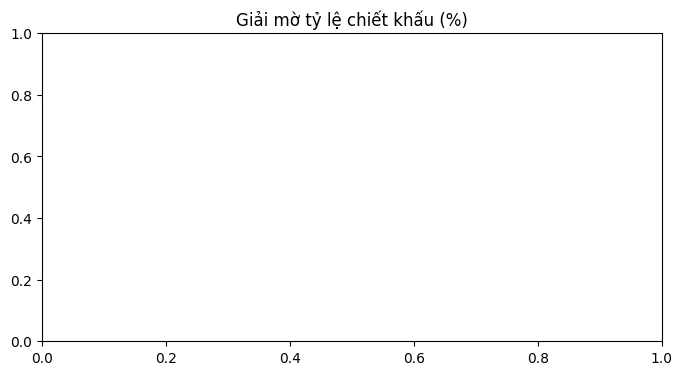

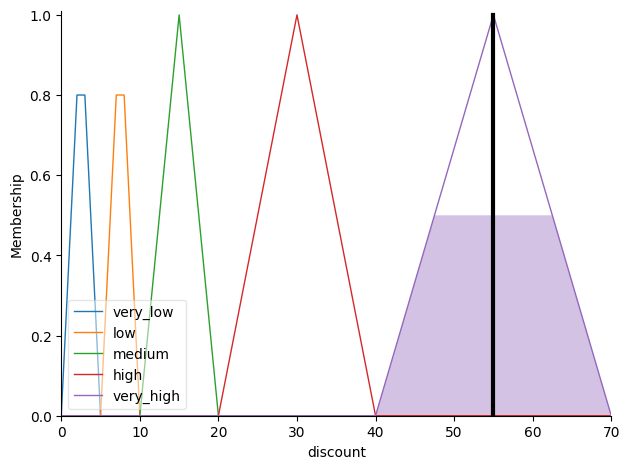

In [ ]:
import numpy as np
import skfuzzy as fuzzy
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

rating = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'rating')
sales_volume = ctrl.Antecedent(np.arange(0, 1001, 1), 'sales_volume')
profit_margin = ctrl.Antecedent(np.arange(0, 101, 1), 'profit_margin')
seasonal_event = ctrl.Antecedent(np.arange(0, 11, 1), 'seasonal_event')
competitor_discount = ctrl.Antecedent(np.arange(0, 101, 1), 'competitor_discount')


discount = ctrl.Consequent(np.arange(0, 71, 1), 'discount')


rating['low'] = fuzzy.trimf(rating.universe, [0, 0, 4.0])
rating['medium'] = fuzzy.trimf(rating.universe, [4.0, 4.25, 4.5])
rating['high'] = fuzzy.trimf(rating.universe, [4.5, 5.0, 5.0])


sales_volume['low'] = fuzzy.trimf(sales_volume.universe, [0, 0, 300])
sales_volume['medium'] = fuzzy.trimf(sales_volume.universe, [200, 500, 800])
sales_volume['high'] = fuzzy.trimf(sales_volume.universe, [700, 1000, 1000])


profit_margin['low'] = fuzzy.trimf(profit_margin.universe, [0, 0, 30])
profit_margin['medium'] = fuzzy.trimf(profit_margin.universe, [20, 50, 80])
profit_margin['high'] = fuzzy.trimf(profit_margin.universe, [70, 100, 100])


seasonal_event['none'] = fuzzy.trimf(seasonal_event.universe, [0, 0, 3])
seasonal_event['moderate'] = fuzzy.trimf(seasonal_event.universe, [2, 5, 8])
seasonal_event['high'] = fuzzy.trimf(seasonal_event.universe, [7, 10, 10])

competitor_discount['low'] = fuzzy.trimf(competitor_discount.universe, [0, 0, 30])
competitor_discount['medium'] = fuzzy.trimf(competitor_discount.universe, [20, 50, 80])
competitor_discount['high'] = fuzzy.trimf(competitor_discount.universe, [70, 100, 100])


discount['very_low'] = fuzzy.trimf(discount.universe, [0, 2.5, 5])
discount['low'] = fuzzy.trimf(discount.universe, [5, 7.5, 10])
discount['medium'] = fuzzy.trimf(discount.universe, [10, 15, 20])
discount['high'] = fuzzy.trimf(discount.universe, [20, 30, 40])
discount['very_high'] = fuzzy.trimf(discount.universe, [40, 55, 70])


rules = [
    ctrl.Rule(rating['high'] & sales_volume['high'] & profit_margin['high'], discount['very_low']),

    ctrl.Rule(rating['low'] & sales_volume['low'] & profit_margin['high'], discount['high']),


    ctrl.Rule(seasonal_event['high'] & competitor_discount['high'], discount['very_high']),

    ctrl.Rule(rating['medium'] & sales_volume['medium'] & profit_margin['medium'], discount['medium']),

    ctrl.Rule(competitor_discount['low'] & profit_margin['low'] & sales_volume['high'], discount['very_low']),
      ctrl.Rule(rating['low'] & seasonal_event['none'], discount['medium']),

    ctrl.Rule(sales_volume['low'] & profit_margin['low'], discount['very_high'])
]

shopee_ctrl = ctrl.ControlSystem(rules)
shopee_sim = ctrl.ControlSystemSimulation(shopee_ctrl)

shopee_sim.input['rating'] = 4.3
shopee_sim.input['sales_volume'] = 500
shopee_sim.input['profit_margin'] = 15
shopee_sim.input['seasonal_event'] = 9
shopee_sim.input['competitor_discount'] = 85

shopee_sim.compute()


print(f"--- KẾT QUẢ CHIẾN LƯỢC SHOPEE ---")
print(f"Mức chiết khấu đề xuất: {shopee_sim.output['discount']:.2f}%")

fig, ax1 = plt.subplots(figsize=(8, 4))
discount.view(sim=shopee_sim, ax=ax1)
ax1.set_title('Giải mờ tỷ lệ chiết khấu (%)')
plt.tight_layout()
plt.show()

Mức giảm giá đề xuất cho sản phẩm: 20.00%


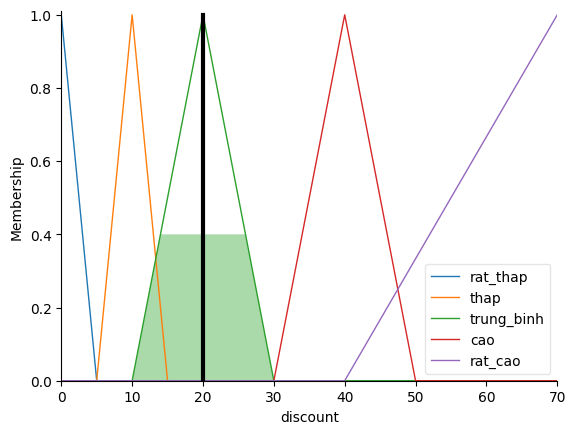

In [ ]:
import numpy as np
import skfuzzy as fuzzy
from skfuzzy import control as ctrl


demand = ctrl.Antecedent(np.arange(0, 11, 1), 'demand')
competition = ctrl.Antecedent(np.arange(0, 11, 1), 'competition')
margin = ctrl.Antecedent(np.arange(0, 11, 1), 'margin')
season = ctrl.Antecedent(np.arange(0, 11, 1), 'season')


discount = ctrl.Consequent(np.arange(0, 71, 1), 'discount')

demand['thap'] = fuzzy.trimf(demand.universe, [0, 0, 5])
demand['trung_binh'] = fuzzy.trimf(demand.universe, [0, 5, 10])
demand['cao'] = fuzzy.trimf(demand.universe, [5, 10, 10])

competition['thap'] = fuzzy.trimf(competition.universe, [0, 0, 5])
competition['trung_binh'] = fuzzy.trimf(competition.universe, [0, 5, 10])
competition['cao'] = fuzzy.trimf(competition.universe, [5, 10, 10])

margin['thap'] = fuzzy.trimf(margin.universe, [0, 0, 5])
margin['trung_binh'] = fuzzy.trimf(margin.universe, [0, 5, 10])
margin['cao'] = fuzzy.trimf(margin.universe, [5, 10, 10])

season['khong'] = fuzzy.trimf(season.universe, [0, 0, 5])
season['trung_binh'] = fuzzy.trimf(season.universe, [0, 5, 10])
season['cao'] = fuzzy.trimf(season.universe, [5, 10, 10])


discount['rat_thap'] = fuzzy.trimf(discount.universe, [0, 0, 5])
discount['thap'] = fuzzy.trimf(discount.universe, [5, 10, 15])
discount['trung_binh'] = fuzzy.trimf(discount.universe, [10, 20, 30])
discount['cao'] = fuzzy.trimf(discount.universe, [30, 40, 50])
discount['rat_cao'] = fuzzy.trimf(discount.universe, [40, 70, 70])


rule1 = ctrl.Rule(demand['cao'] & competition['thap'] & margin['thap'], discount['rat_thap'])
rule2 = ctrl.Rule(demand['thap'] & competition['cao'] & margin['cao'], discount['cao'])
rule3 = ctrl.Rule(margin['trung_binh'] & season['cao'], discount['trung_binh'])
rule4 = ctrl.Rule(competition['cao'] & season['cao'] & margin['cao'], discount['rat_cao'])
rule7 = ctrl.Rule(margin['cao'] & competition['trung_binh'] & season['trung_binh'], discount['trung_binh'])


discount_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule7])
discount_sim = ctrl.ControlSystemSimulation(discount_ctrl)


discount_sim.input['demand'] = 10
discount_sim.input['competition'] = 5
discount_sim.input['margin'] = 10
discount_sim.input['season'] = 8


discount_sim.compute()

print(f"Mức giảm giá đề xuất cho sản phẩm: {discount_sim.output['discount']:.2f}%")
discount.view(sim=discount_sim)

--- KẾT QUẢ ĐIỀU PHỐI LOGISTICS ---
-----------------------------------
Số lượng đơn nên kết hợp: 8.14/10 (Mức: 8.1)
Mức độ ưu tiên giao hàng: 8.14/10


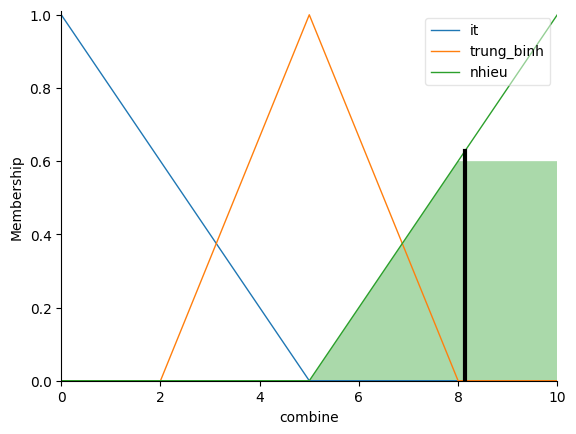

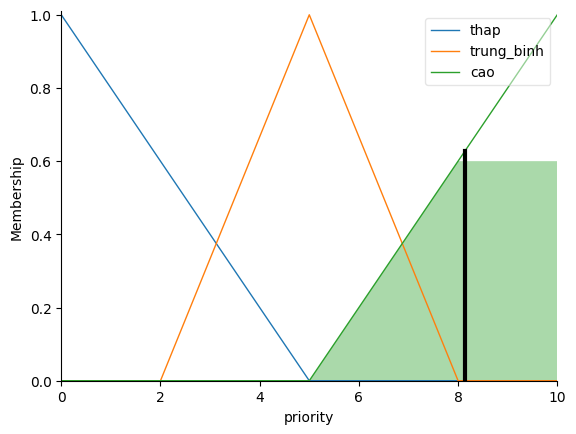

In [ ]:


import numpy as np
import skfuzzy as fuzzy
from skfuzzy import control as ctrl


demand = ctrl.Antecedent(np.arange(0, 11, 1), 'demand')
distance = ctrl.Antecedent(np.arange(0, 11, 1), 'distance')
stock = ctrl.Antecedent(np.arange(0, 11, 1), 'stock')


combine = ctrl.Consequent(np.arange(0, 11, 1), 'combine')
priority = ctrl.Consequent(np.arange(0, 11, 1), 'priority')

for var in [demand, distance, stock]:
    var['low'] = fuzzy.trimf(var.universe, [0, 0, 5])
    var['mid'] = fuzzy.trimf(var.universe, [2, 5, 8])
    var['high'] = fuzzy.trimf(var.universe, [5, 10, 10])


combine['it'] = fuzzy.trimf(combine.universe, [0, 0, 5])
combine['trung_binh'] = fuzzy.trimf(combine.universe, [2, 5, 8])
combine['nhieu'] = fuzzy.trimf(combine.universe, [5, 10, 10])


priority['thap'] = fuzzy.trimf(priority.universe, [0, 0, 5])
priority['trung_binh'] = fuzzy.trimf(priority.universe, [2, 5, 8])
priority['cao'] = fuzzy.trimf(priority.universe, [5, 10, 10])


rule1 = ctrl.Rule(demand['high'] & distance['high'], combine['nhieu'])
rule2 = ctrl.Rule(demand['low'] & distance['low'], combine['it'])
rule3 = ctrl.Rule(stock['low'], priority['cao'])
rule4 = ctrl.Rule(demand['mid'] | distance['mid'], [combine['trung_binh'], priority['trung_binh']])
rule5 = ctrl.Rule(demand['high'] & stock['high'], priority['cao'])


logistics_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5])
logistics_sim = ctrl.ControlSystemSimulation(logistics_ctrl)



logistics_sim.input['demand'] = 9
logistics_sim.input['distance'] = 8
logistics_sim.input['stock'] = 2


logistics_sim.compute()


print("--- KẾT QUẢ ĐIỀU PHỐI LOGISTICS ---")
print("-" * 35)

print(f"Số lượng đơn nên kết hợp: {logistics_sim.output['combine']:.2f}/10 (Mức: {logistics_sim.output['combine']:.1f})")
print(f"Mức độ ưu tiên giao hàng: {logistics_sim.output['priority']:.2f}/10")


combine.view(sim=logistics_sim)
priority.view(sim=logistics_sim)